In [14]:
from kymotools.detect import Detector
from kymotools.interactive import retain_tracks_by_id
from n2v.models import N2V

import kymotools.io as kio
import math
import numpy as np
import os

/Users/sc13967/Documents/Programming/Python/dna-tethering-by-cohesin/.pixi/envs/n2v/lib/python3.12/site-packages/kymotools/interactive.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Distance ($\mu$m)', fontsize=12)
/Users/sc13967/Documents/Programming/Python/dna-tethering-by-cohesin/.pixi/envs/n2v/lib/python3.12/site-packages/kymotools/interactive.py:127: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Distance ($\mu$m)')


In [17]:
# Parameters
path = "/Users/sc13967/Library/CloudStorage/OneDrive-UniversityofBristol/People/Gemma Fisher/2026-09-28 Photobleaching step counting (N2V)/r/"
channel = 0

In [18]:
# Loading N2V model
model_name = '2024-02-02_Cropped_Keras'
basedir = '../n2v-models/'
model = N2V(config=None, name=model_name, basedir=basedir)

Loading network weights from '2024-02-02_Cropped_Keras.h5'.


In [19]:
# Step fitting
def fit_steps(tracks, image,WinSize=300,LMthresh=300,half_x_w=1):
    for track in tracks.values():
        track.measure_intensity(image,half_x_w=half_x_w)
        find_change_points(track,WinSize=WinSize,LMthresh=LMthresh)

# The following methods are translated from the BaLM MATLAB tool, which itself was based on the publication Watkins and Yang, J. Phys. Chem. B, Vol. 109, No. 1
def find_change_points(track, WinSize=300, LMthresh=300):
    time = np.array(list(track.intensity.keys()))
    data = np.array(list(track.intensity.values()))

    nData = len(data)
    ChangePnt = np.zeros(data.shape)
    ChangePnt[0] = 1
    ChangePnt[-1] = 1

    crntChange = 0
    nxtChange = nData
    nCPnt = 1

    while crntChange < nData-1:
        if (nxtChange-crntChange) > WinSize:
            datain=data[(crntChange+1):nxtChange]
            (Cpt, LM) = _LRtest(datain)
            
            if LM>LMthresh:
                ChangePnt[crntChange+Cpt]=1
                nCPnt=nCPnt+1
                nxtChange=crntChange+Cpt
            else:
                crntChange=nxtChange
                if crntChange<nData-1:
                    nxtChange=nxtChange+1
                    while ChangePnt[nxtChange]==0:
                        nxtChange=nxtChange+1

        else:
            crntChange=nxtChange
            if crntChange<nData-1:
                nxtChange=nxtChange+1
                while ChangePnt[nxtChange]==0:
                    nxtChange=nxtChange+1

    tCPnt = np.where(ChangePnt != 0)[0]
    
    track.step_trace={}
    for j in range(nCPnt):
        Ilevel=sum(data[tCPnt[j]+1:tCPnt[j+1]])/(tCPnt[j+1]-tCPnt[j])
        for i in range(tCPnt[j]+1,tCPnt[j+1]+1):
            track.step_trace[time[i]] = Ilevel
    track.step_trace[time[0]] = track.step_trace[time[1]]
    track.step_trace = dict(sorted(track.step_trace.items()))
    
    # Remove "step" at 0 and the end, then convert indices to timepoints
    tCPnt = tCPnt[np.where(tCPnt!=0)]
    tCPnt = tCPnt[np.where(tCPnt<time[-5])]
    tCPnt = time[tCPnt]
    track.steps = tCPnt

def _LRtest(datain):
        nd=len(datain)
        L = np.zeros(nd)

        SS = sum(datain[:])
        S = np.cumsum(datain)

        LM=0
        Cpt=0
        for k in range(nd):
            if S[k] > 0 and SS-S[k] > 0:
                L[k]=S[k]*math.log(S[k]/(k+1))+(SS-S[k])*math.log((SS-S[k])/(nd-(k+1)))-SS*math.log(SS/nd)
                if LM<L[k]:
                    LM=L[k]
                    Cpt=k

        return (Cpt,LM)
    
# Function to process single image
def process_image(det_image,image,channel,output_name):
    # Initialising Detector
    detector = Detector(half_t_w=0,peak_det_thresh = 0.5, n_max=10, a_lb = 0.5, c_lb=3, c_ub=7, c_def=4, max_dist=15, min_track_length = 10,
                    track_heritage_weight=100, starting_window=10)

    # Detect peaks and track
    tracks = detector.detect(det_image)
    
    # Removing tracks
    display(kio.create_track_overlay(tracks,image))
    retain_tracks_by_id(tracks)

    # Measuring intensity
    for track in tracks.values():
        track.measure_intensity(image)
    
    # # Step fitting (to be added later)
    fit_steps(tracks, image, WinSize=50, LMthresh=10)

    # Saving files
    kio.save_overlay(tracks,image,output_name+"_overlay")
    kio.write_track_data(tracks,output_name+"_traces")
    kio.save_plots(tracks,output_name+"_traces")
    kio.write_change_points(tracks,output_name+'_steps')

Processing:  20231206-162309 Marker 15_kymo15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step


 50%|█████     | 1/2 [00:00<00:00, 53092.46it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step


100%|██████████| 1251/1251 [00:04<00:00, 296.30it/s]


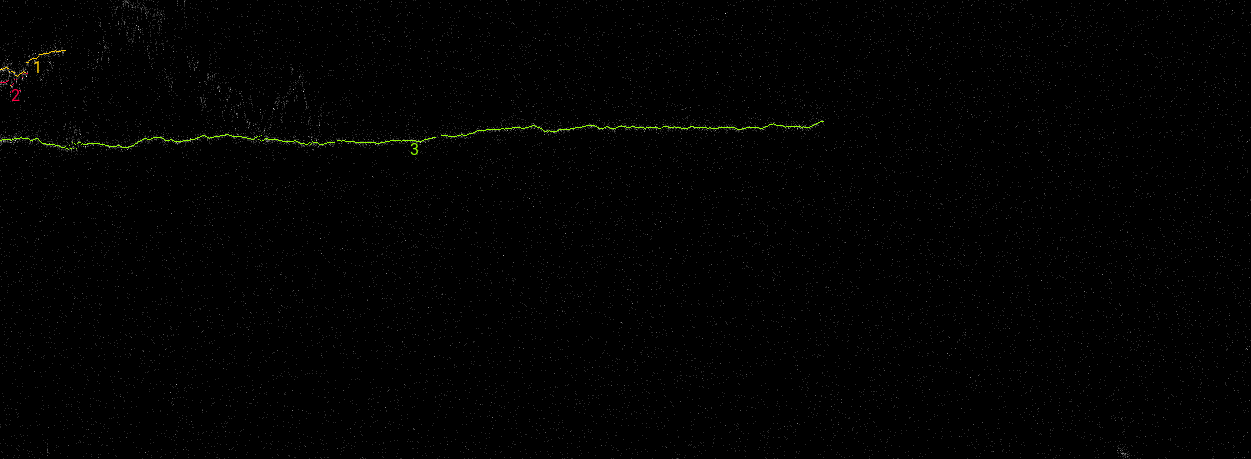

Processing:  20231206-161613 Marker 14_kymo14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


 50%|█████     | 1/2 [00:00<00:00, 77672.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


100%|██████████| 272/272 [00:00<00:00, 685.55it/s]


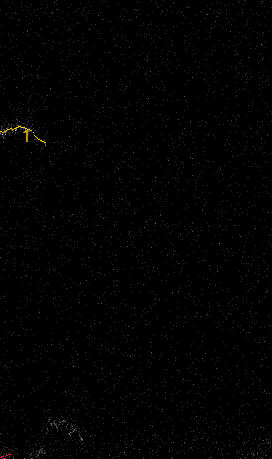

Processing:  20231206-170443 Marker 18_kymo18
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step


 50%|█████     | 1/2 [00:00<00:00, 110376.42it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


100%|██████████| 450/450 [00:18<00:00, 24.00it/s] 


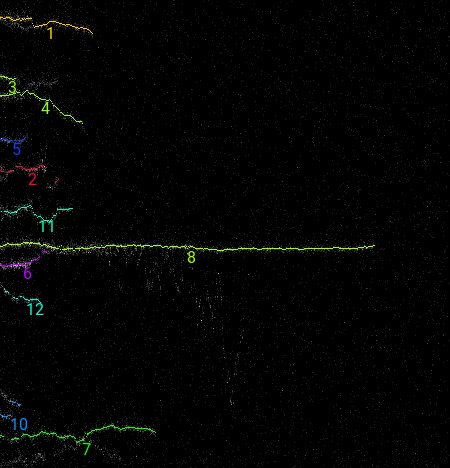

Processing:  20231206-145259 Marker 8_kymo7
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step


 50%|█████     | 1/2 [00:00<00:00, 50533.78it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step


100%|██████████| 1113/1113 [00:04<00:00, 259.89it/s]


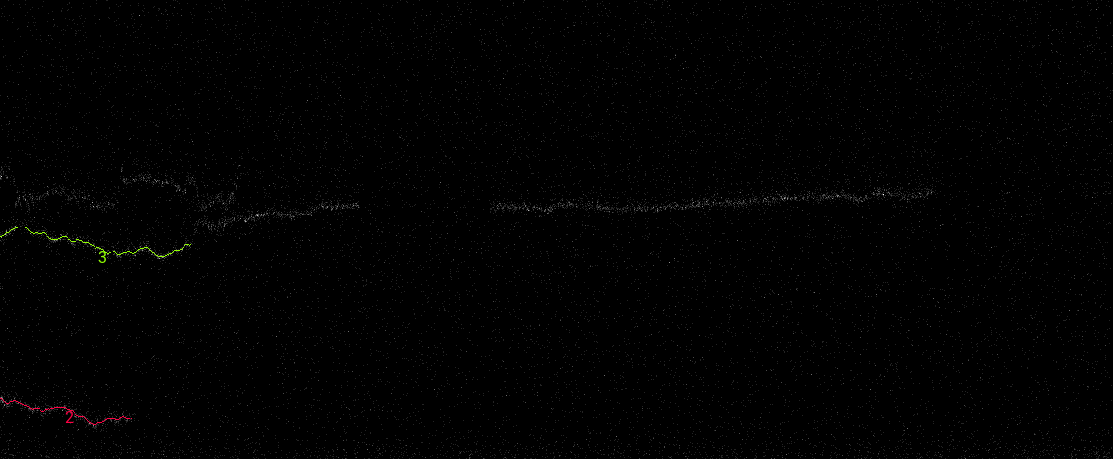

Processing:  20231206-155430 Marker 12_kymo12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


 50%|█████     | 1/2 [00:00<00:00, 58254.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


100%|██████████| 746/746 [00:07<00:00, 99.27it/s] 


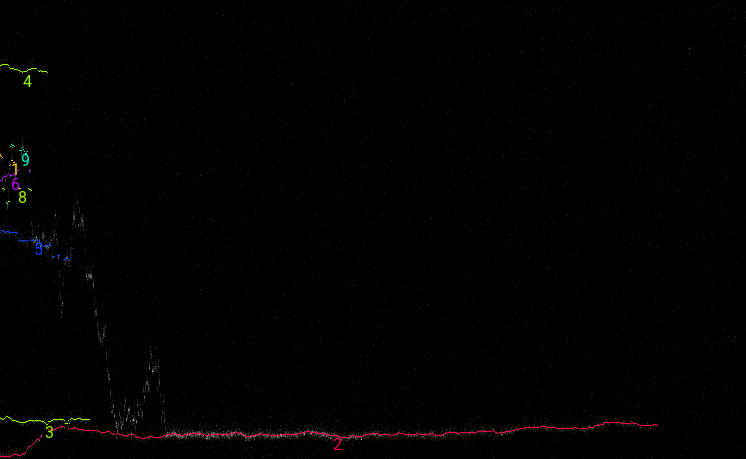

Processing:  20231206-160757 Marker 13_kymo13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step


 50%|█████     | 1/2 [00:00<00:00, 123361.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step


100%|██████████| 825/825 [00:04<00:00, 184.45it/s]


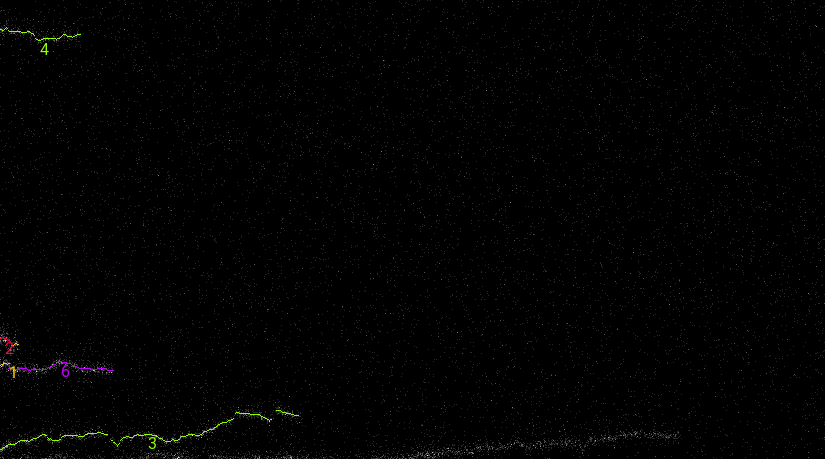

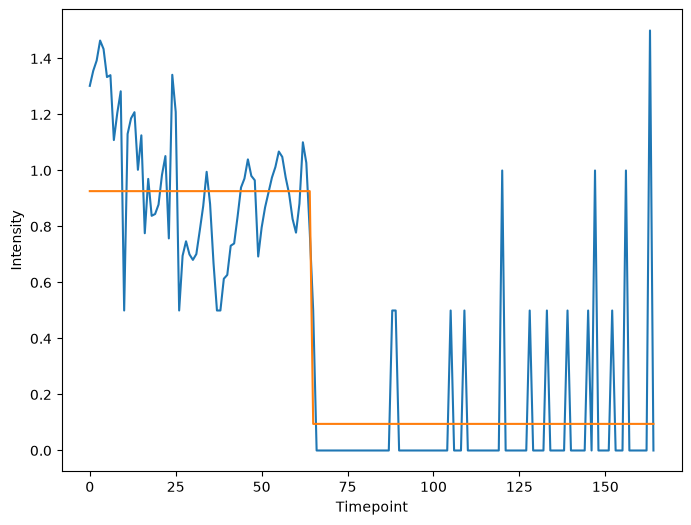

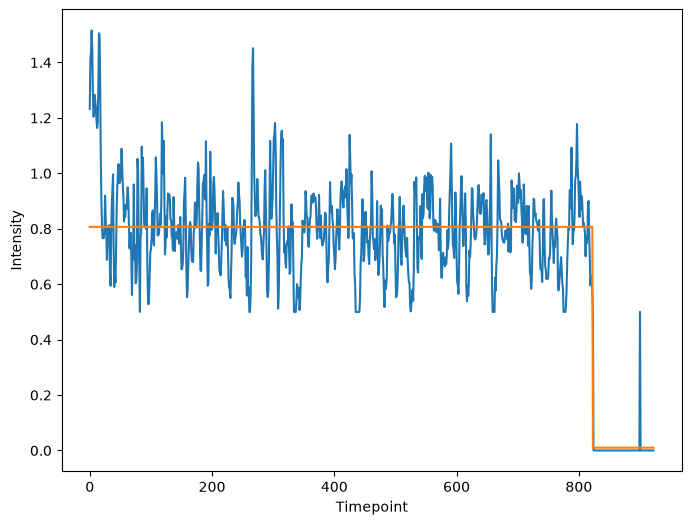

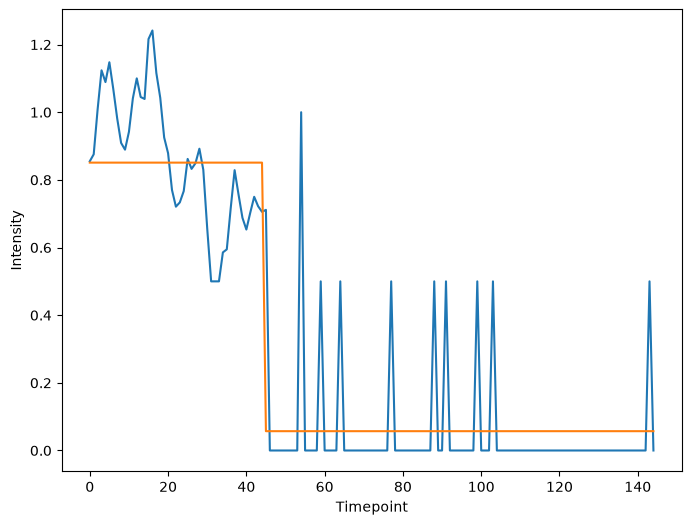

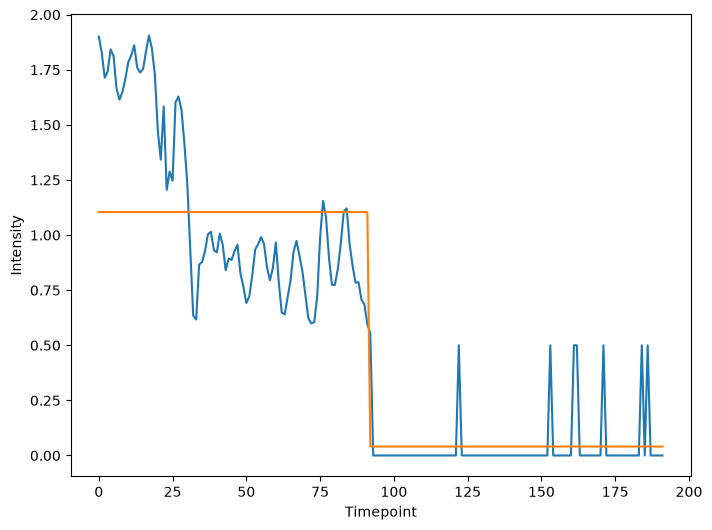

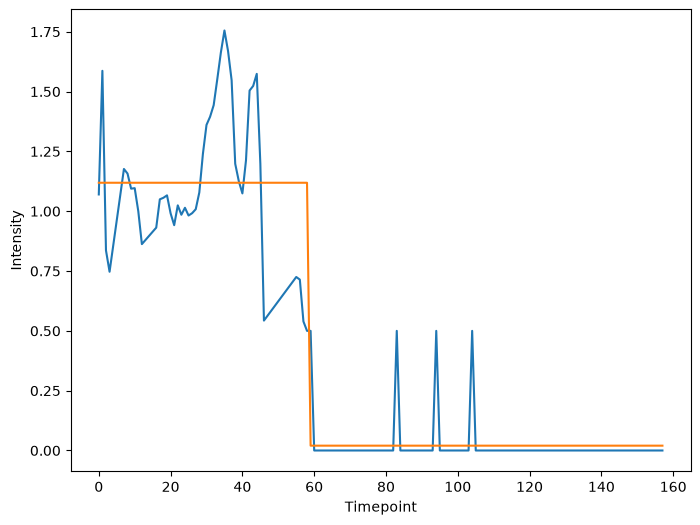

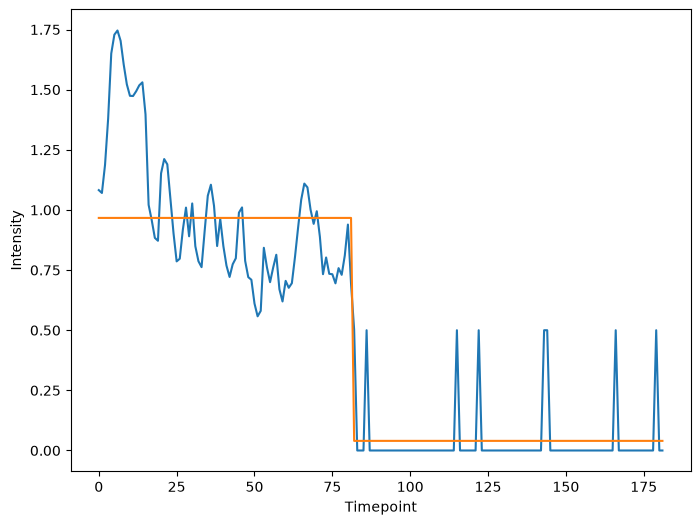

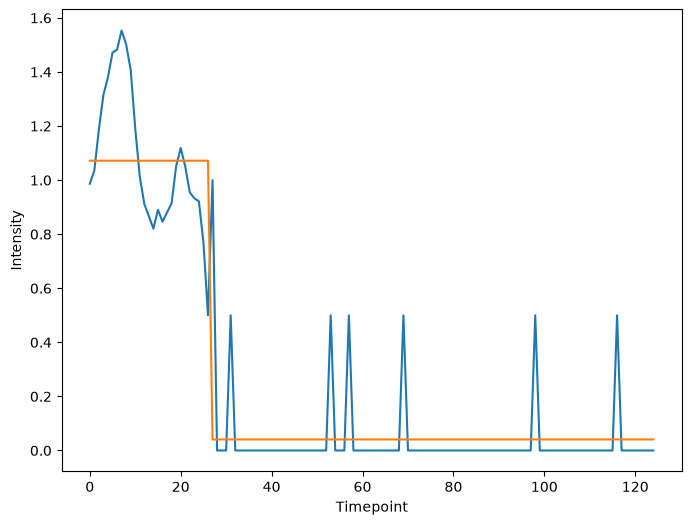

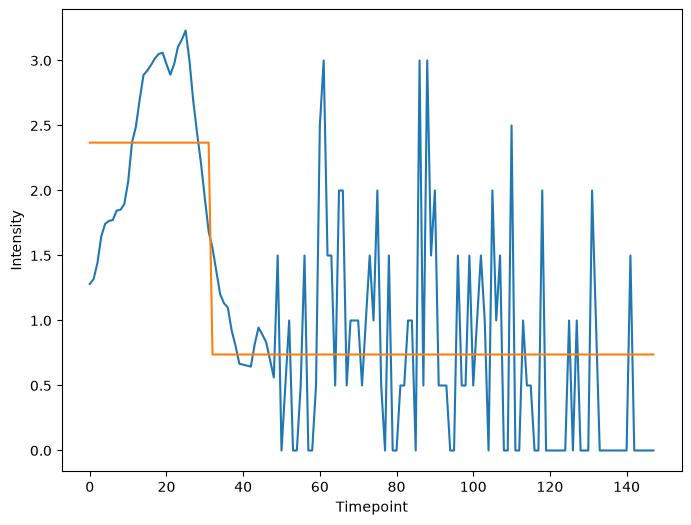

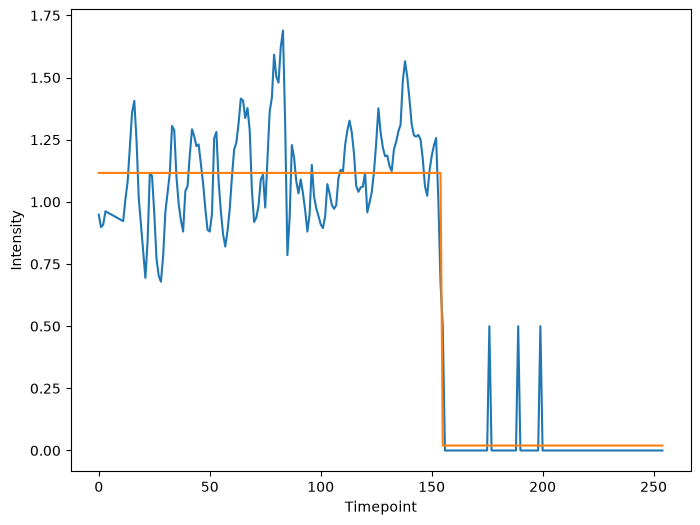

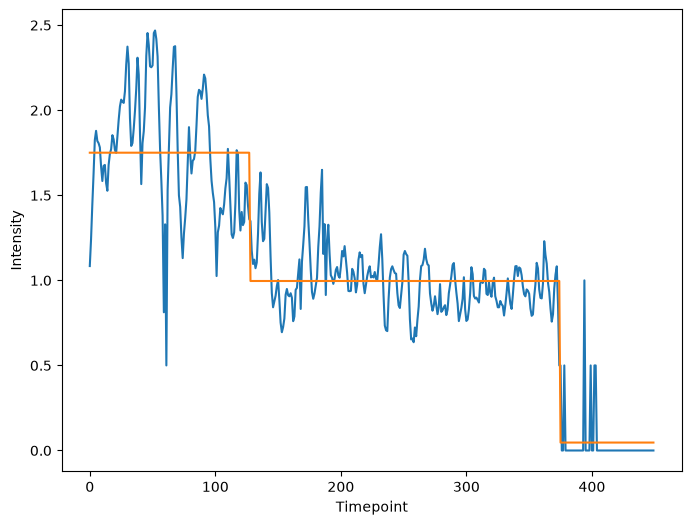

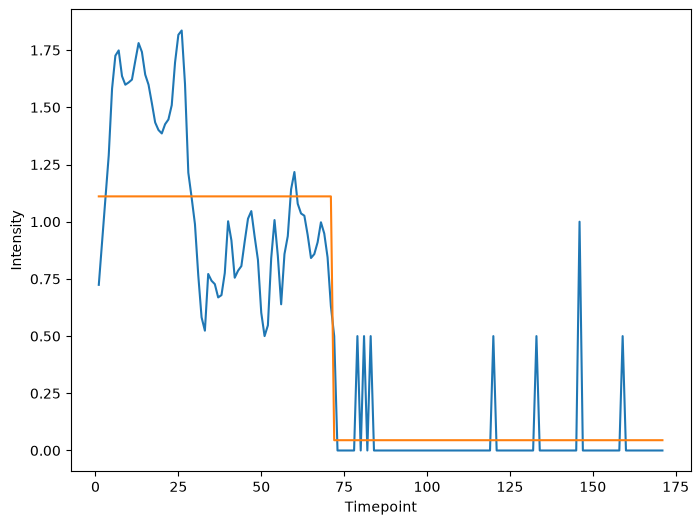

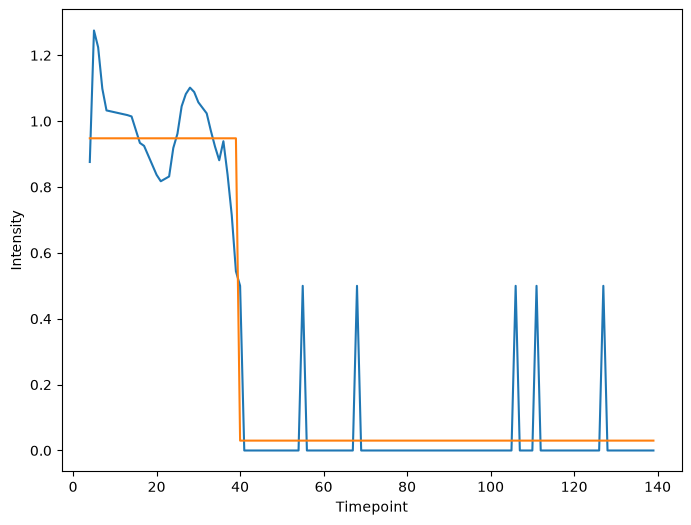

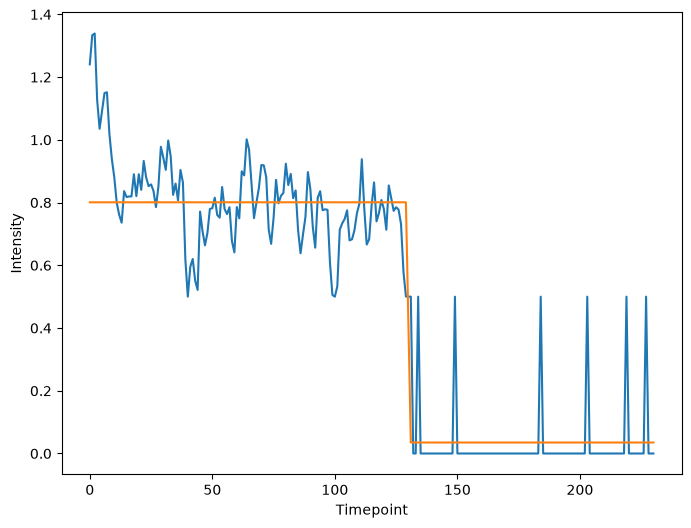

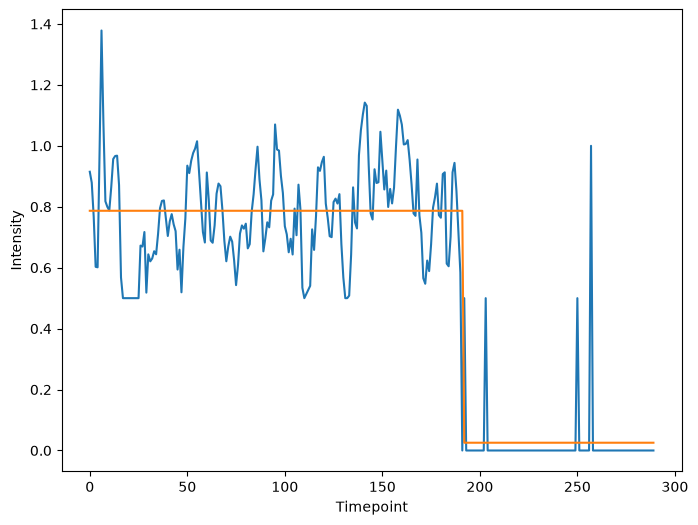

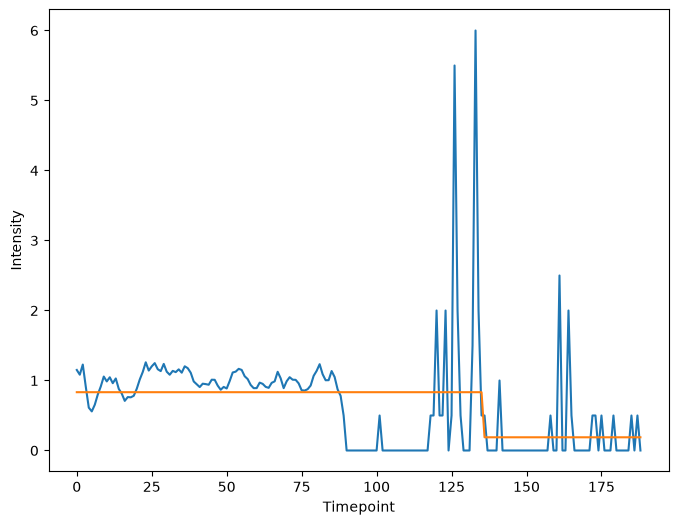

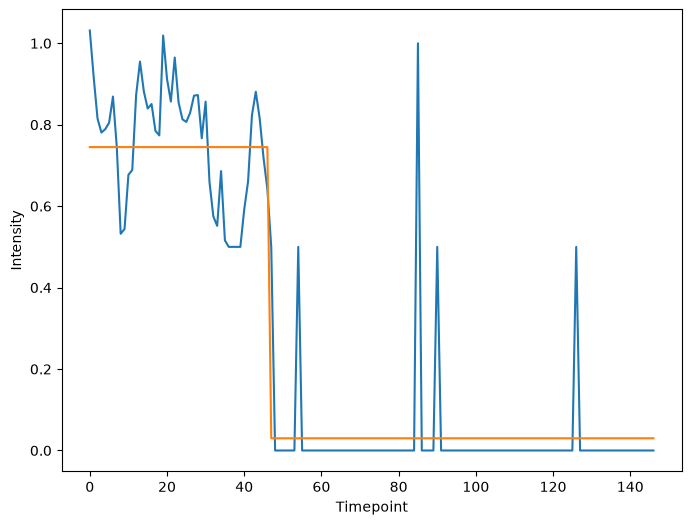

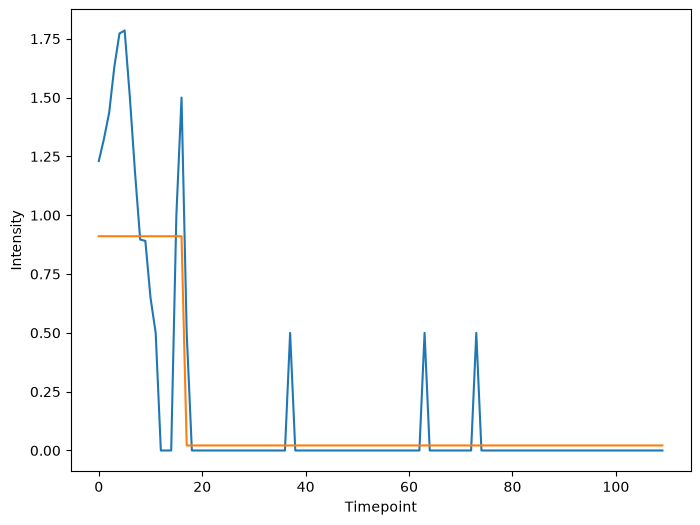

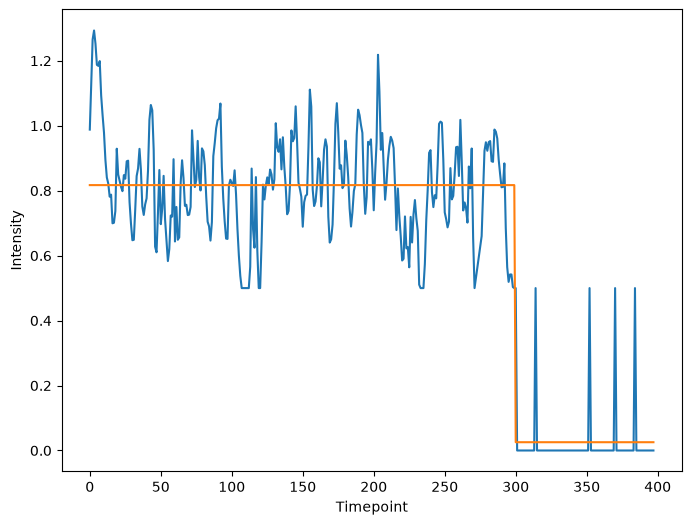

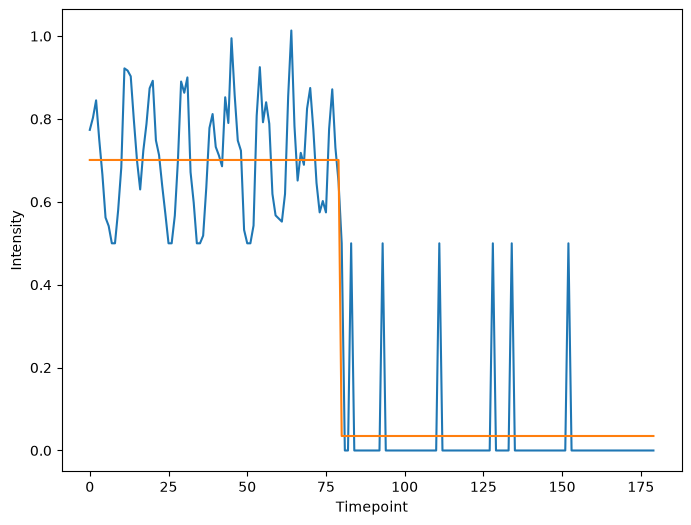

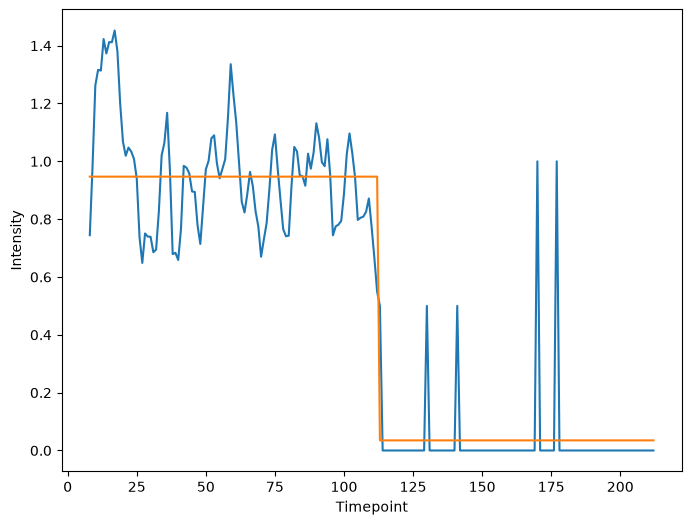

In [20]:
import matplotlib.pyplot as plt

# Loading image and calculating paths
for f in os.listdir(path):
    name = os.path.basename(os.path.splitext(f)[0])
    if os.path.splitext(f)[1] == ".tif":
        print("Processing: ",name)
        image = kio.read_image(path+f,channel,x_range=None)
        det_image = model.predict(image, axes='YX', n_tiles=(2,1))
        det_image = det_image - np.min(det_image[:])
        output_name = path+name+'_C'+str(channel)
        process_image(det_image, image, channel, output_name)